# Train Eval Experiment 

### Import Library

In [68]:
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# import SKlearn FFNN
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# import custom module
from ffnn import FFNN, Layer

#### Import Dataset

In [69]:
X_train_classification = np.load('dataset/classification/X_train_final.npy')
y_train_classification = np.load('dataset/classification/y_train_final.npy')
X_test_classification = np.load('dataset/classification/X_test_final.npy')
y_test_classification = np.load('dataset/classification/y_test_final.npy')

# Cek shape data
print(f"X_train classification shape    : {X_train_classification.shape}")
print(f"y_train classification shape    : {y_train_classification.shape}")
print(f"X_test classification shape     : {X_test_classification.shape}")
print(f"y_test classification shape     : {y_test_classification.shape}")

X_train_regression = np.load('dataset/regression/X_train_final.npy')
y_train_regression = np.load('dataset/regression/y_train_final.npy')
X_test_regression = np.load('dataset/regression/X_test_final.npy')
y_test_regression = np.load('dataset/regression/y_test_final.npy')

# Cek shape data
print(f"X_train regression shape        : {X_train_regression.shape}")
print(f"y_train regression shape        : {y_train_regression.shape}")
print(f"X_test regression shape         : {X_test_regression.shape}")
print(f"y_test regression shape         : {y_test_regression.shape}")

X_train classification shape    : (9844, 21)
y_train classification shape    : (9844,)
X_test classification shape     : (2000, 21)
y_test classification shape     : (2000,)
X_train regression shape        : (8000, 20)
y_train regression shape        : (8000, 1)
X_test regression shape         : (2000, 20)
y_test regression shape         : (2000, 1)


In [70]:
def plot_results(res, lyr=-2, is_cls=True):
    # 1. loss plot compare
    plt.figure(figsize=(10, 4))
    for n, d in res.items(): plt.plot(d['history']['train_loss'], label=n)
    plt.title("Loss Comparison"); plt.legend(); plt.grid(True); plt.show()

    # 2. weight, grad, confMatrix
    for n, d in res.items():
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 3))
        
        # Weights
        ax1.hist(d['model'].layers[lyr].weights.ravel(), bins=30, alpha=0.6)
        ax1.set_title(f"{n} Weights")
        
        # Gradd
        ax2.hist(d['model'].layers[lyr].d_weights.ravel(), bins=30, color='orange', alpha=0.6)
        ax2.set_title(f"{n} Grads")
        
        # confMatrix
        if is_cls:
            cm = confusion_matrix(d['y_true'].flatten(), (d['y_pred'] > 0.5).astype(int).flatten())
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax3, cbar=False)
            ax3.set_title(f"{n} ConfMatrix")
        else:
            ax3.scatter(d['y_true'], d['y_pred'], alpha=0.3)
            ax3.plot([d['y_true'].min(), d['y_true'].max()], [d['y_true'].min(), d['y_true'].max()], 'r--')
            ax3.set_title(f"{n} Pred vs True")
            
        plt.tight_layout(); plt.show()
        
        # score
        if is_cls:
            acc = accuracy_score(d['y_true'].flatten(), (d['y_pred'] > 0.5).astype(int).flatten())
            print(f">>> {n:15} | Accuracy: {acc:.4f}")
        else:
            print(f">>> {n:15} | MSE: {mean_squared_error(d['y_true'], d['y_pred']):.4f}")


## Experiment Hyperparameter

## Experiment Fungsi Aktivasi

### Calssification

##### SKLearn

In [71]:
# activations test
sklearn_activations = ['identity', 'relu', 'logistic', 'tanh']
sklearn_models = {}

for activation in sklearn_activations:
    mlp = MLPClassifier(
        hidden_layer_sizes=(32, 16, 8),
        activation=activation,   
        solver='sgd',
        learning_rate_init=0.01,
        max_iter=50,
        batch_size=32,
        random_state=42
    )
    mlp.fit(X_train_classification, y_train_classification)
    sklearn_models[activation] = mlp
    print(f"Finish model {activation}")

Finish model identity


/home/astha/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Finish model relu


/home/astha/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Finish model logistic
Finish model tanh


/home/astha/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


In [72]:
# Evaluation
for activation, model in sklearn_models.items():
    y_pred = model.predict(X_test_classification)
    acc = accuracy_score(y_test_classification, y_pred)
    print(f"Accuracy for {activation}: {acc:.4f}")
    print(f"Classification Report for {activation}:\n{classification_report(y_test_classification, y_pred)}")
    print(f"Confusion Matrix for {activation}:\n{confusion_matrix(y_test_classification, y_pred)}\n")
    

Accuracy for identity: 0.7360
Classification Report for identity:
              precision    recall  f1-score   support

           0       0.65      0.69      0.67       769
           1       0.80      0.77      0.78      1231

    accuracy                           0.74      2000
   macro avg       0.72      0.73      0.72      2000
weighted avg       0.74      0.74      0.74      2000

Confusion Matrix for identity:
[[527 242]
 [286 945]]

Accuracy for relu: 0.7180
Classification Report for relu:
              precision    recall  f1-score   support

           0       0.66      0.55      0.60       769
           1       0.74      0.83      0.78      1231

    accuracy                           0.72      2000
   macro avg       0.70      0.69      0.69      2000
weighted avg       0.71      0.72      0.71      2000

Confusion Matrix for relu:
[[ 420  349]
 [ 215 1016]]

Accuracy for logistic: 0.7445
Classification Report for logistic:
              precision    recall  f1-score   

##### Custom FFNN

Trained: linear
Trained: relu
Trained: tanh
Trained: leaky_relu
Trained: elu


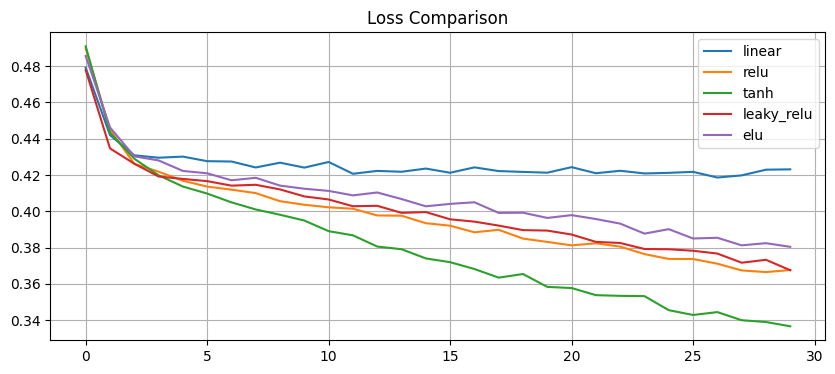

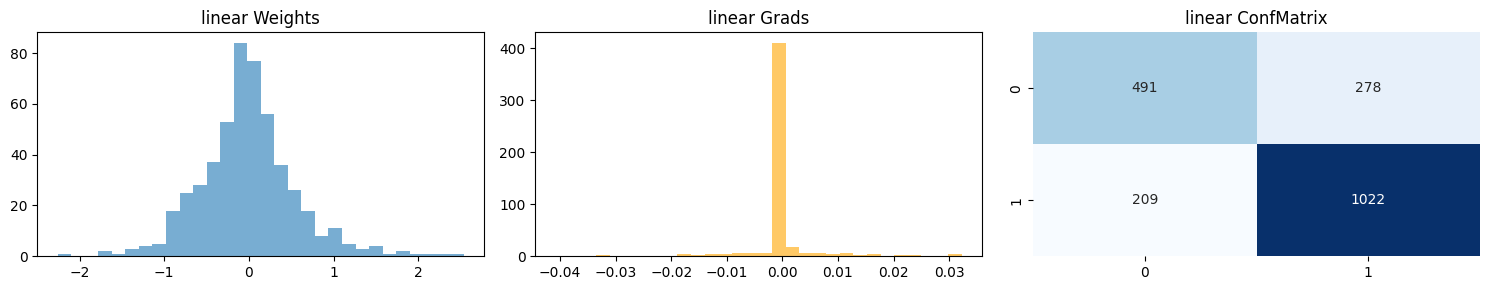

>>> linear          | Accuracy: 0.7565


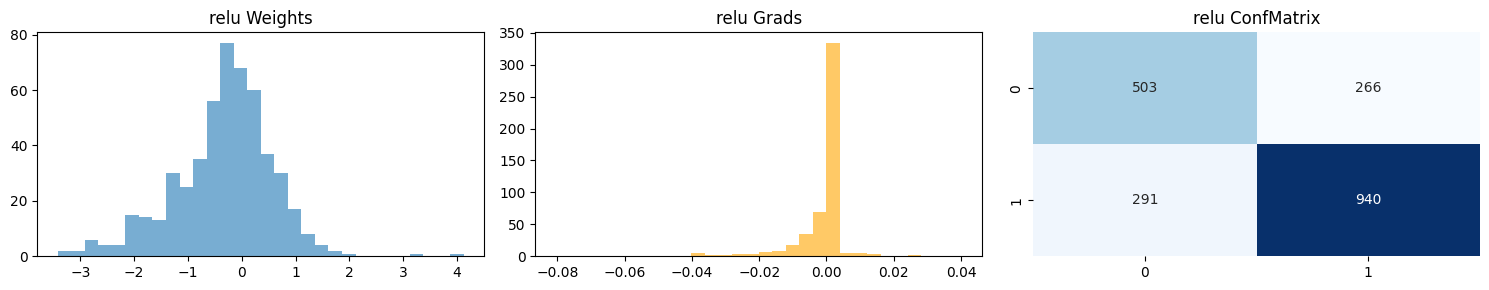

>>> relu            | Accuracy: 0.7215


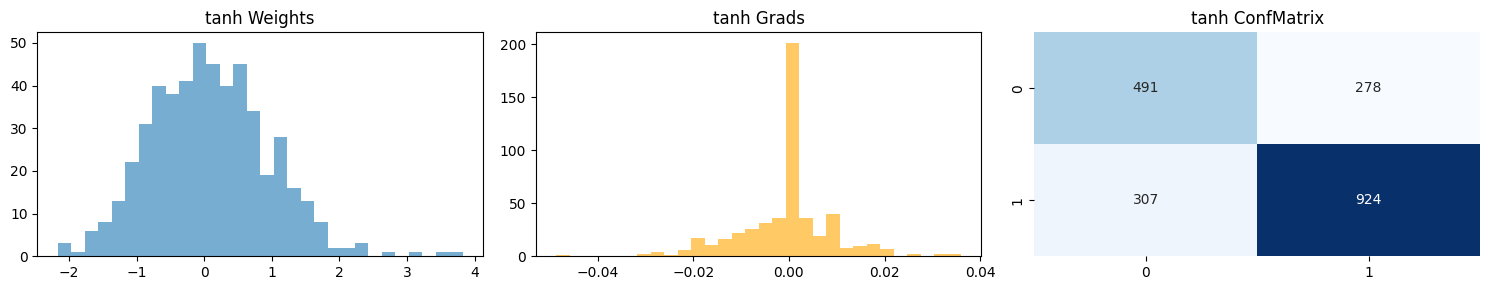

>>> tanh            | Accuracy: 0.7075


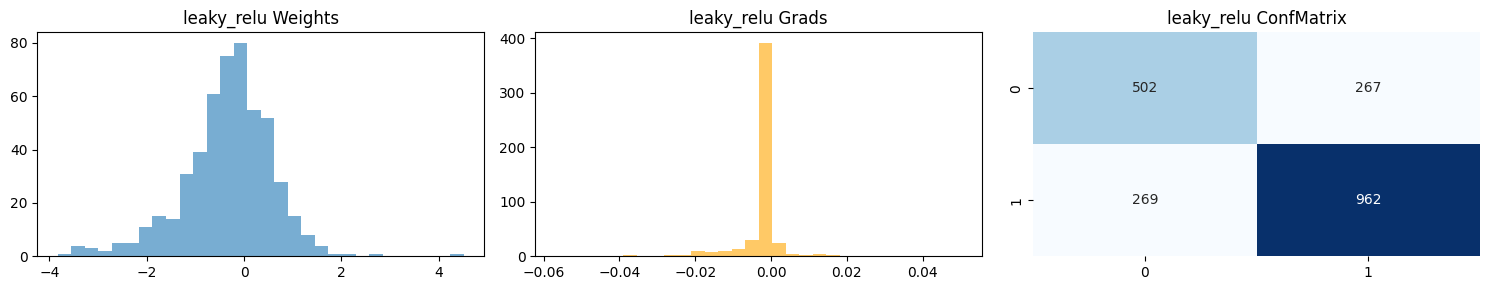

>>> leaky_relu      | Accuracy: 0.7320


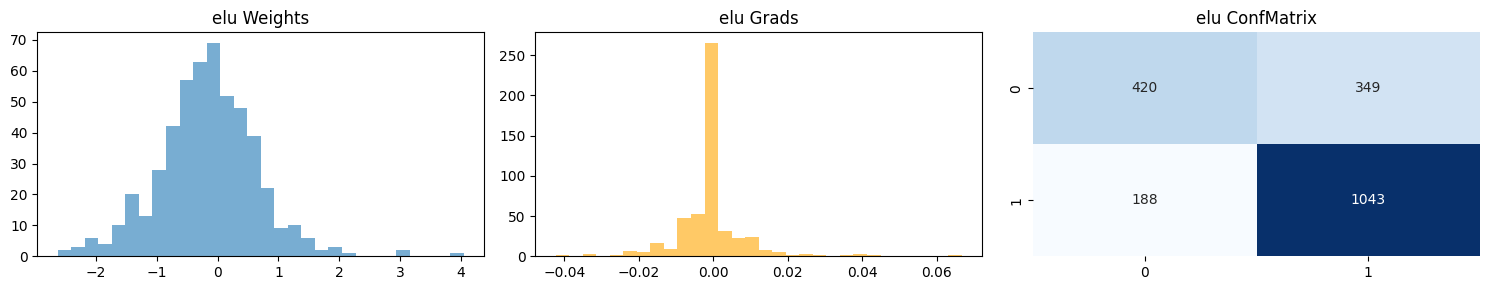

>>> elu             | Accuracy: 0.7315


In [ ]:
activations = ['linear', 'relu', 'tanh', 'leaky_relu', 'elu']
results = {}

for act in activations:
    m = FFNN(loss='bce')
    m.add(Layer(21, 32, activation=act, init_method='he'))
    m.add(Layer(32, 16, activation='relu', init_method='he'))
    m.add(Layer(16, 1, activation='sigmoid', init_method='xavier'))

    # fit silent
    h = m.fit(X_train_classification, y_train_classification.reshape(-1, 1), 
                        epochs=30, batch_size=32, verbose=0)
    
    results[act] = {'model': m, 'history': h, 'y_true': y_test_classification, 'y_pred': m.predict(X_test_classification)}
    print(f"Trained: {act}")

plot_results(results)

### Regresi

#### Arsitektur 1

##### SKLearn

In [74]:
from sklearn.neural_network import MLPRegressor

# activations test
sklearn_models_reg = {}

for activation in sklearn_activations:
    mlp_reg = MLPRegressor(
        hidden_layer_sizes=(32, 16),
        activation=activation,   
        solver='adam',
        learning_rate_init=0.01,
        max_iter=100,
        batch_size=32,
        random_state=42
    )
    mlp_reg.fit(X_train_regression, y_train_regression)
    sklearn_models_reg[activation] = mlp_reg
    print(f"Finish model {activation}")

/home/astha/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1645: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Finish model identity


/home/astha/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1645: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/home/astha/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/astha/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1645: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Finish model relu


/home/astha/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/astha/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:1645: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Finish model logistic
Finish model tanh


/home/astha/.local/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


In [75]:
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
# evaluasi

for activation in sklearn_activations:
    y_pred = sklearn_models_reg[activation].predict(X_test_regression)
    mse = mean_squared_error(y_test_regression, y_pred)
    r2 = r2_score(y_test_regression, y_pred)
    print(f"SKLearn Regression {activation}         - MSE: {mse:.4f}, R2 Score: {r2:.4f}")

SKLearn Regression identity         - MSE: 2.2553, R2 Score: 0.0210
SKLearn Regression relu         - MSE: 2.5995, R2 Score: -0.1285
SKLearn Regression logistic         - MSE: 2.7992, R2 Score: -0.2152
SKLearn Regression tanh         - MSE: 2.8653, R2 Score: -0.2439


## Experiment Learning Rate

## Experiment Regularisasi